# Housing Price Prediction: A Comparative Study of Regularization Techniques

<b>Authors:</b> Reuben Thomas, Maguel, Nicole

<b>Date:</b> May 04, 2025

<b>Description</b>: This notebook analyzes the Ames Housing dataset using linear,
              Ridge, and Lasso regression (with and without feature engineering)


In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set up plotting parameters
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Read the data using pandas
df = pd.read_csv("AmesHousing.csv")
df.columns = df.columns.str.replace(' ', '')
print(f"DataFrame loaded with shape: {df.shape}")


DataFrame loaded with shape: (2930, 82)


## Part 1: Exploratory Data Analysis

### Basic Dataset Information
Here we take a look at some basic characteristics of the dataset in order to ensure we handle it appropriately moving forward. We'll look at things like:
- The number of records and features and other summary statistics
- Determine missing values
- Look at the general distribution of Sale Prices and resolve any skewness
- Analyze multicollinearity between features
- Vizualize relationship between SalePrice and a few important categorical variables

In [2]:
# Display basic information about the dataset
print("Dataset Information:")
print(f"Number of records: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")
print("\nFirst few rows of the dataset:")
df.head()

Dataset Information:
Number of records: 2930
Number of features: 82

First few rows of the dataset:


,Order,PID,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [3]:
# Summary statistics
print("\nSummary statistics for numerical features:")
df.describe()


Summary statistics for numerical features:


,Order,PID,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemod/Add,MasVnrArea,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [4]:
# Check for missing values
missing_values = df.isnull().sum()
print("\nMissing values per column:")
print(missing_values[missing_values > 0])
print(f"Total missing values: {missing_values.sum()}")


Missing values per column:
LotFrontage      490
Alley           2732
MasVnrType      1775
MasVnrArea        23
BsmtQual          80
BsmtCond          80
BsmtExposure      83
BsmtFinType1      80
BsmtFinSF1         1
BsmtFinType2      81
BsmtFinSF2         1
BsmtUnfSF          1
TotalBsmtSF        1
Electrical         1
BsmtFullBath       2
BsmtHalfBath       2
FireplaceQu     1422
GarageType       157
GarageYrBlt      159
GarageFinish     159
GarageCars         1
GarageArea         1
GarageQual       159
GarageCond       159
PoolQC          2917
Fence           2358
MiscFeature     2824
dtype: int64
Total missing values: 15749


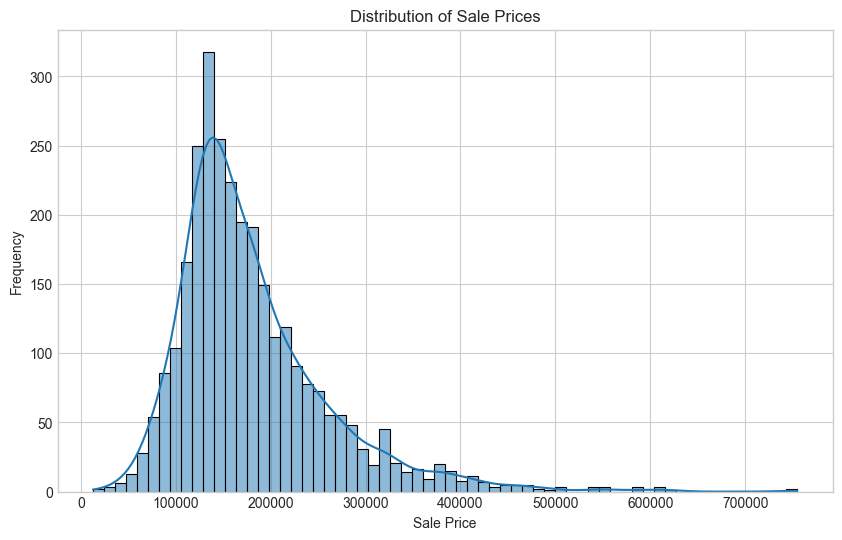

In [5]:
# Target variable analysis
plt.figure(figsize=(10, 6))
sns.histplot(df['SalePrice'], kde=True)
plt.title('Distribution of Sale Prices')
plt.xlabel('Sale Price')
plt.ylabel('Frequency')
plt.show()

### Checking for skewness


Skewness of Sale Price: 1.74
Since sale Price is positively skewed, we should consider log transformation:


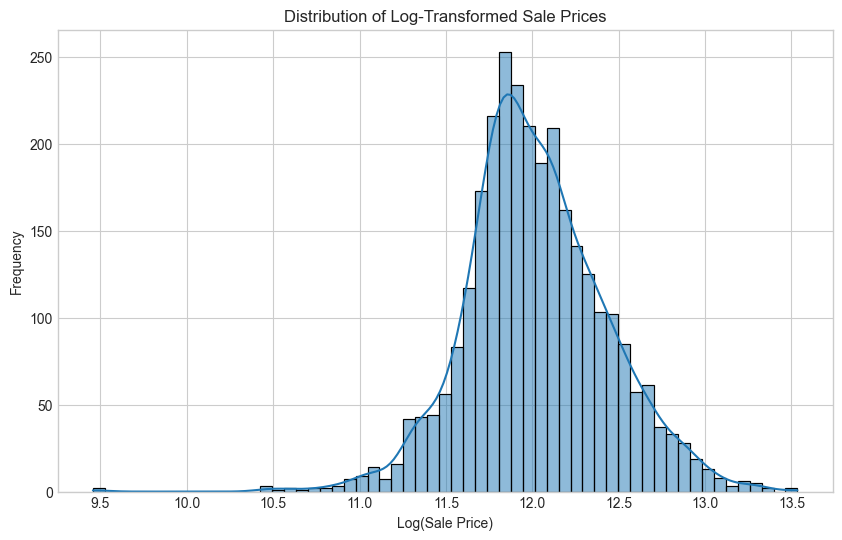

In [6]:
# Check for skewness in Sales Price
skewness = df['SalePrice'].skew()
print(f"\nSkewness of Sale Price: {skewness:.2f}")
if skewness > 0.5:
    print("Since sale Price is positively skewed, we should consider log transformation:")
    df['SalePrice_Log'] = np.log1p(df['SalePrice'])
    plt.figure(figsize=(10, 6))
    sns.histplot(df['SalePrice_Log'], kde=True)
    plt.title('Distribution of Log-Transformed Sale Prices')
    plt.xlabel('Log(Sale Price)')
    plt.ylabel('Frequency')
    plt.show()

### Correlation Analyisis

Here we look at the multicollinearlity between features in the dataset, and determining which ones are most correlated with Sales Price.

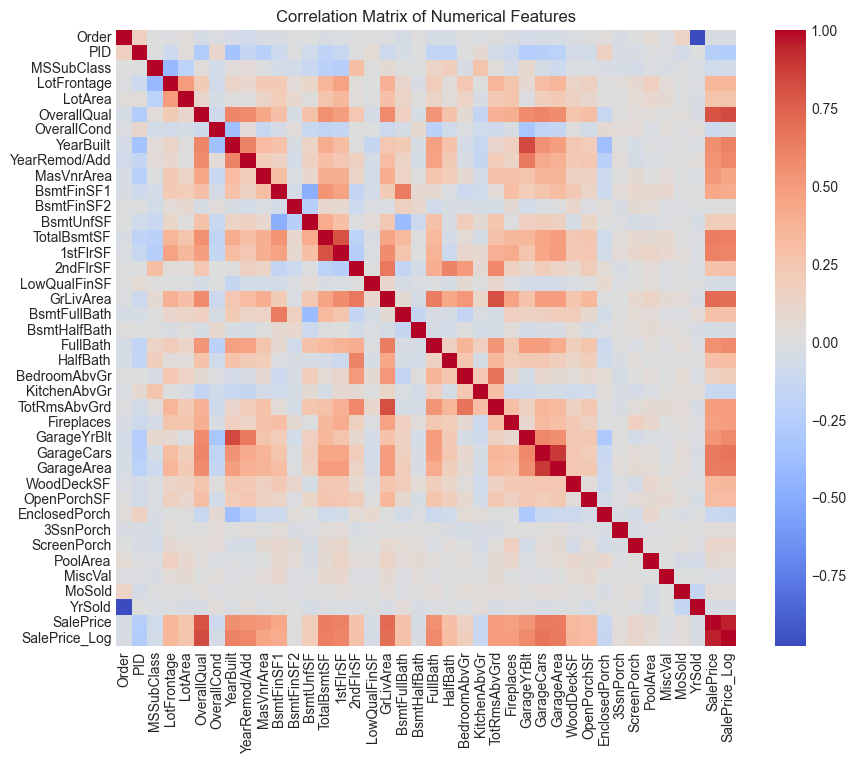

In [7]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'Id' in numerical_features:
    numerical_features.remove('Id')  # Remove Id as it's just an identifier

correlation_matrix = df[numerical_features].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False, fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [8]:
# Top correlations with SalePrice
top_corr = correlation_matrix['SalePrice'].sort_values(ascending=False)
print("\nTop 10 features correlated with Sale Price:")
top_corr[:12]  # 12 because SalePrice and SalePrice_Log is included


Top 10 features correlated with Sale Price:


SalePrice        1.000000
SalePrice_Log    0.946304
OverallQual      0.799262
GrLivArea        0.706780
GarageCars       0.647877
GarageArea       0.640401
TotalBsmtSF      0.632280
1stFlrSF         0.621676
YearBuilt        0.558426
FullBath         0.545604
YearRemod/Add    0.532974
GarageYrBlt      0.526965
Name: SalePrice, dtype: float64

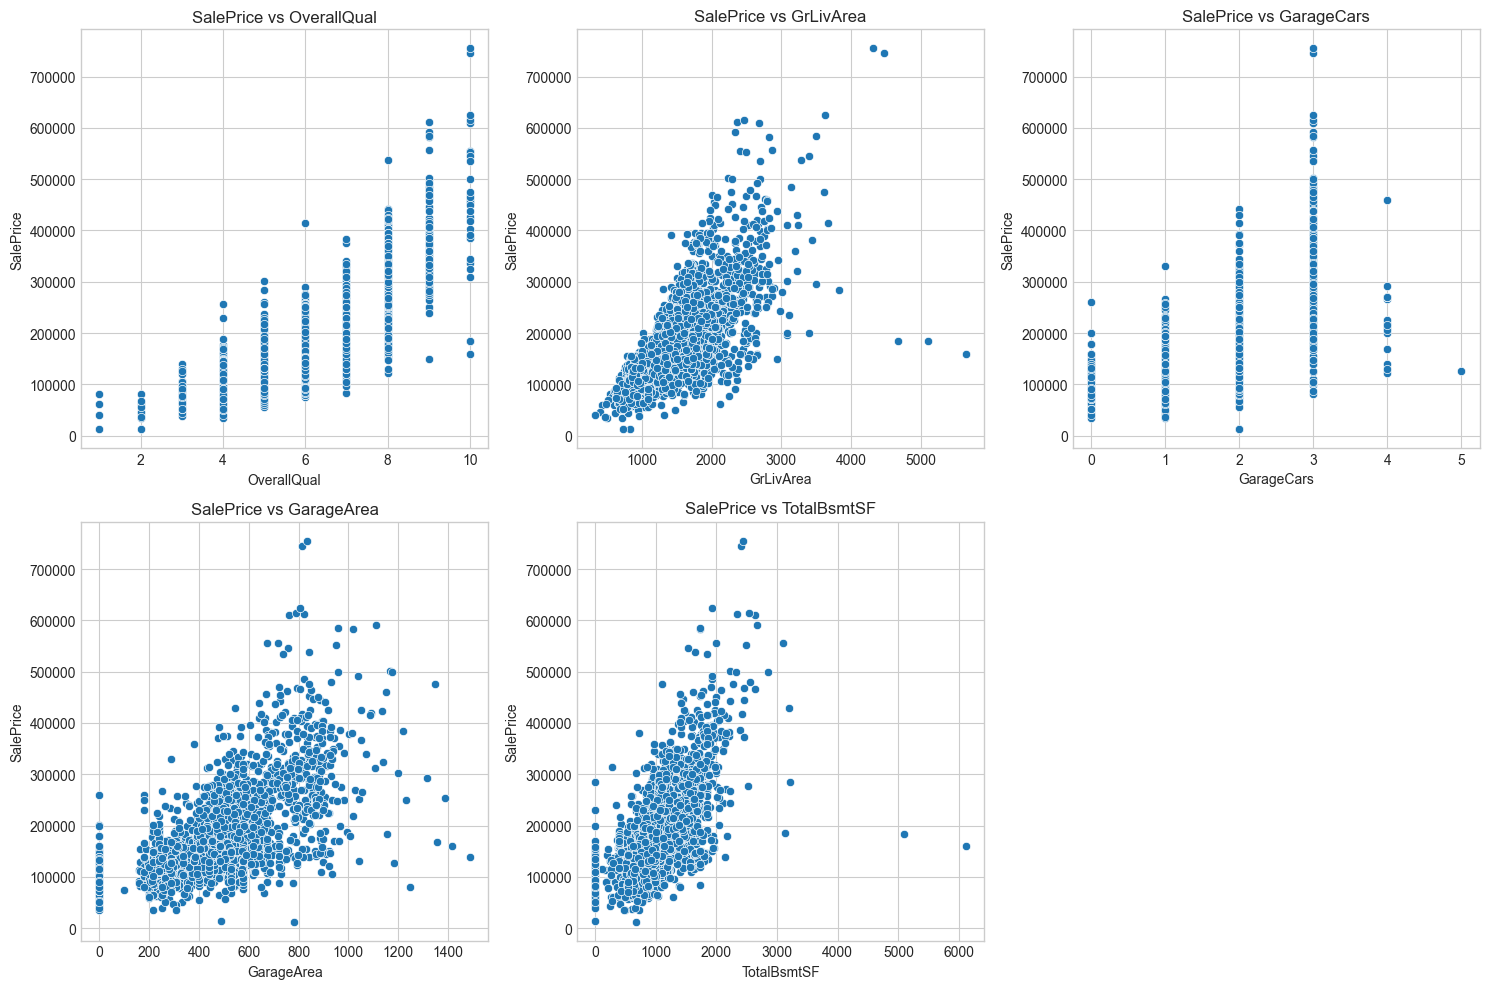

In [9]:
# Scatter plots for top correlated features
top_5_features = top_corr[2:7].index.tolist()  # Exclude SalePrice and SalePrice_Log
plt.figure(figsize=(15, 10))
for i, feature in enumerate(top_5_features):
    plt.subplot(2, 3, i+1)
    sns.scatterplot(x=feature, y='SalePrice', data=df)
    plt.title(f'SalePrice vs {feature}')
plt.tight_layout()
plt.show()

### Categorical Features Analysis
Now we'll analyze some categorical features features and their relationship with sales price.


Number of categorical features: 43
Categorical features: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


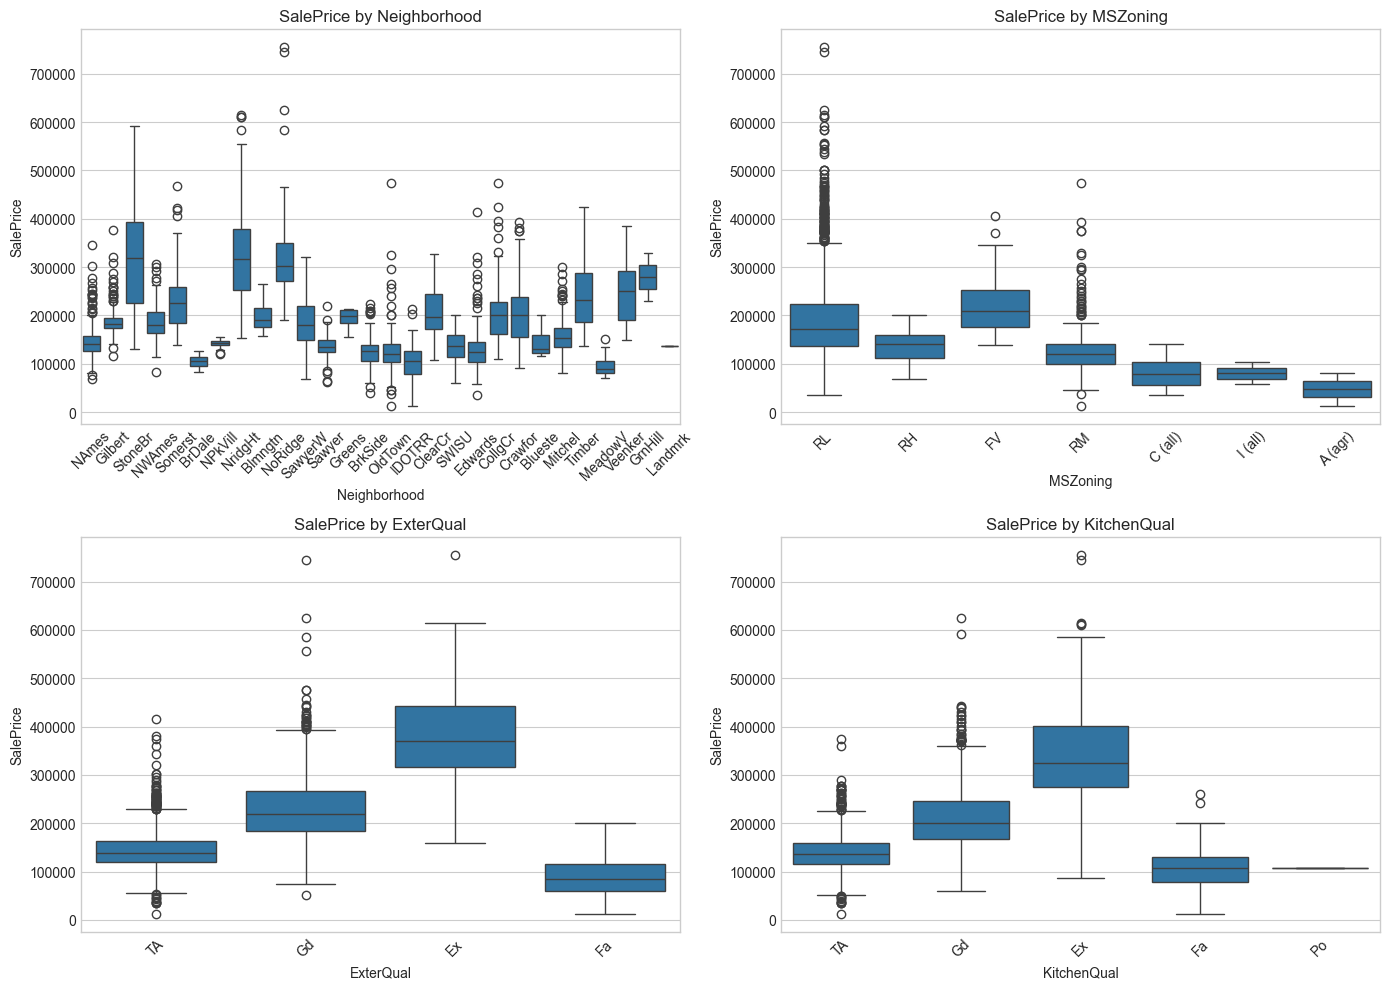

In [10]:
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nNumber of categorical features: {len(categorical_features)}")
print("Categorical features:", categorical_features)

# Analyzing a few important categorical features
important_cat_features = ['Neighborhood', 'MSZoning', 'ExterQual', 'KitchenQual']
available_cat_features = [f for f in important_cat_features if f in df.columns]
if available_cat_features:
    plt.figure(figsize=(14, 10))
    for i, feature in enumerate(available_cat_features):
        plt.subplot(2, 2, i+1)
        sns.boxplot(x=feature, y='SalePrice', data=df)
        plt.title(f'SalePrice by {feature}')
        plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Part 2: Feature Engineering

Here we will:
1. Handle missing values
2. Create new features
3. Encode Quality/Condition Features as ordinal data
4. Log-Transform any skewed numeric features
5. Create dummy variables for categorical features in order to convert them into numerical features

### Handle missing values

In [11]:
# Create a copy of original dataframe without feature engineering for comparison
df_no_fe = df.copy()

# Make a copy of the dataframe for feature engineering
df_fe = df.copy()

# Fill missing values for LotFrontage using median grouped by neighborhood
if 'LotFrontage' in df_fe.columns and df_fe['LotFrontage'].isnull().sum() > 0:
    print("Filling missing LotFrontage values by neighborhood median...")
    df_fe['LotFrontage'] = df_fe.groupby('Neighborhood')['LotFrontage'].transform(
        lambda x: x.fillna(x.median()) if not x.median() != x.median() else x.fillna(df_fe['LotFrontage'].median())
    )

# Helper function to handle NA values in categorical features
def handle_na_categorical(df, column, replacement='None'):
    if column in df.columns:
        # Check if column has NA values
        na_count = df[column].isna().sum()
        if na_count > 0:
            print(f"Replacing {na_count} NA values in {column} with '{replacement}'")
            df[column] = df[column].fillna(replacement)
    return df

# Handle common NA values in categorical columns based on data dictionary
for col in ['Alley', 'MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 
           'BsmtFinType2', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 
           'GarageCond', 'PoolQC', 'Fence', 'MiscFeature']:
    if col in df_fe.columns:
        df_fe = handle_na_categorical(df_fe, col)

Filling missing LotFrontage values by neighborhood median...
Replacing 2732 NA values in Alley with 'None'
Replacing 1775 NA values in MasVnrType with 'None'
Replacing 80 NA values in BsmtQual with 'None'
Replacing 80 NA values in BsmtCond with 'None'
Replacing 83 NA values in BsmtExposure with 'None'
Replacing 80 NA values in BsmtFinType1 with 'None'
Replacing 81 NA values in BsmtFinType2 with 'None'
Replacing 1422 NA values in FireplaceQu with 'None'
Replacing 157 NA values in GarageType with 'None'
Replacing 159 NA values in GarageFinish with 'None'
Replacing 159 NA values in GarageQual with 'None'
Replacing 159 NA values in GarageCond with 'None'
Replacing 2917 NA values in PoolQC with 'None'
Replacing 2358 NA values in Fence with 'None'
Replacing 2824 NA values in MiscFeature with 'None'


### Create new features

In [12]:
# print(df_fe.columns)

# Create house age features
current_year = 2025  # Using current year as reference
if 'YearBuilt' in df_fe.columns:
    df_fe['HouseAge'] = current_year - df_fe['YearBuilt']
    print("Created 'HouseAge' feature")

if 'YearRemodAdd' in df_fe.columns and 'YearBuilt' in df_fe.columns:
    df_fe['YearsSinceRemodel'] = current_year - df_fe['YearRemodAdd']
    df_fe['IsRemodeled'] = (df_fe['YearRemodAdd'] != df_fe['YearBuilt']).astype(int)
    print("Created 'YearsSinceRemodel' and 'IsRemodeled' features")

# Create total area feature
area_columns = ['TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'GrLivArea']
available_area_cols = [col for col in area_columns if col in df_fe.columns]
if len(available_area_cols) > 0:
    df_fe['TotalSF'] = df_fe[available_area_cols].sum(axis=1)
    print("Created 'TotalSF' feature")

# Create overall quality/condition interaction
if 'OverallQual' in df_fe.columns and 'OverallCond' in df_fe.columns:
    df_fe['OverallQualCond'] = df_fe['OverallQual'] * df_fe['OverallCond']
    print("Created 'OverallQualCond' interaction feature")

# Create bathroom features
bath_columns = ['BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath']
available_bath_cols = [col for col in bath_columns if col in df_fe.columns]
if len(available_bath_cols) > 0:
    # Calculate total bathrooms giving half baths a weight of 0.5
    half_bath_cols = [col for col in available_bath_cols if 'Half' in col]
    full_bath_cols = [col for col in available_bath_cols if 'Full' in col or 'Half' not in col]
    
    df_fe['TotalBath'] = df_fe[full_bath_cols].sum(axis=1) + 0.5 * df_fe[half_bath_cols].sum(axis=1)
    print("Created 'TotalBath' feature")

# Create porch area feature
porch_columns = ['WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch']
available_porch_cols = [col for col in porch_columns if col in df_fe.columns]
if len(available_porch_cols) > 0:
    df_fe['TotalPorchSF'] = df_fe[available_porch_cols].sum(axis=1)
    print("Created 'TotalPorchSF' feature")

# Create feature for houses with pools
if 'PoolArea' in df_fe.columns:
    df_fe['HasPool'] = (df_fe['PoolArea'] > 0).astype(int)
    print("Created 'HasPool' feature")

# Create feature for garage
if 'GarageArea' in df_fe.columns:
    df_fe['HasGarage'] = (df_fe['GarageArea'] > 0).astype(int)
    print("Created 'HasGarage' feature")

# Create feature for fireplace
if 'Fireplaces' in df_fe.columns:
    df_fe['HasFireplace'] = (df_fe['Fireplaces'] > 0).astype(int)
    print("Created 'HasFireplace' feature")

# Create lot ratio features
if 'LotFrontage' in df_fe.columns and 'LotArea' in df_fe.columns:
    # Prevent division by zero
    df_fe['LotRatio'] = df_fe['LotFrontage'] / (df_fe['LotArea'] + 0.001)
    print("Created 'LotRatio' feature")

Created 'HouseAge' feature
Created 'TotalSF' feature
Created 'OverallQualCond' interaction feature
Created 'TotalBath' feature
Created 'TotalPorchSF' feature
Created 'HasPool' feature
Created 'HasGarage' feature
Created 'HasFireplace' feature
Created 'LotRatio' feature


### Encode Quality features 

In [13]:
# Convert quality variables to numerical
quality_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}
quality_columns = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 
                  'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']

for col in quality_columns:
    if col in df_fe.columns:
        if df_fe[col].dtype == 'object':  # Make sure it's a categorical column
            df_fe[f'{col}_Num'] = df_fe[col].map(quality_map).fillna(0)
            print(f"Converted '{col}' to numerical '{col}_Num'")

Converted 'ExterQual' to numerical 'ExterQual_Num'
Converted 'ExterCond' to numerical 'ExterCond_Num'
Converted 'BsmtQual' to numerical 'BsmtQual_Num'
Converted 'BsmtCond' to numerical 'BsmtCond_Num'
Converted 'HeatingQC' to numerical 'HeatingQC_Num'
Converted 'KitchenQual' to numerical 'KitchenQual_Num'
Converted 'FireplaceQu' to numerical 'FireplaceQu_Num'
Converted 'GarageQual' to numerical 'GarageQual_Num'
Converted 'GarageCond' to numerical 'GarageCond_Num'
Converted 'PoolQC' to numerical 'PoolQC_Num'


### Log-Transform any skewed numeric features

In [14]:
# Check for numerical columns with high skewness
numeric_cols = df_fe.select_dtypes(include=['int64', 'float64']).columns
skewed_features = df_fe[numeric_cols].apply(lambda x: stats.skew(x.dropna())).sort_values(ascending=False)
high_skewed = skewed_features[skewed_features > 0.5]

print(f"\nFound {len(high_skewed)} highly skewed numerical features")
print(high_skewed.head(10))  # Print the top 10 most skewed features

# Apply log transformation to highly skewed features
for feature in high_skewed.index:
    # Skip the target or already transformed target
    if feature in ['SalePrice', 'SalePrice_Log', 'Id']:
        continue
    
    # Add a small constant to handle zeros
    if (df_fe[feature] == 0).any():
        df_fe[f'{feature}_Log'] = np.log1p(df_fe[feature])
    else:
        # Use the natural log for strictly positive values
        df_fe[f'{feature}_Log'] = np.log(df_fe[feature])
    
    print(f"Created log-transformed feature '{feature}_Log'")

# Create neighborhood encoding based on mean price
if 'Neighborhood' in df_fe.columns:
    neighborhood_price = df_fe.groupby('Neighborhood')['SalePrice'].mean().to_dict()
    df_fe['Neighborhood_Price'] = df_fe['Neighborhood'].map(neighborhood_price)
    print("Created 'Neighborhood_Price' encoding")

# Count of total rooms vs bedroom ratio
if 'TotRmsAbvGrd' in df_fe.columns and 'BedroomAbvGr' in df_fe.columns:
    # Add small epsilon to prevent division by zero
    df_fe['BedroomRatio'] = df_fe['BedroomAbvGr'] / (df_fe['TotRmsAbvGrd'] + 0.001)
    print("Created 'BedroomRatio' feature")


Found 35 highly skewed numerical features
MiscVal          21.988523
PoolArea         16.930469
PoolQC_Num       16.356570
HasPool          14.912715
LotArea          12.814334
LowQualFinSF     12.111957
3SsnPorch        11.397956
KitchenAbvGr      4.311616
BsmtFinSF2        4.137858
EnclosedPorch     4.012390
dtype: float64
Created log-transformed feature 'MiscVal_Log'
Created log-transformed feature 'PoolArea_Log'
Created log-transformed feature 'PoolQC_Num_Log'
Created log-transformed feature 'HasPool_Log'
Created log-transformed feature 'LotArea_Log'
Created log-transformed feature 'LowQualFinSF_Log'
Created log-transformed feature '3SsnPorch_Log'
Created log-transformed feature 'KitchenAbvGr_Log'
Created log-transformed feature 'BsmtFinSF2_Log'
Created log-transformed feature 'EnclosedPorch_Log'
Created log-transformed feature 'ScreenPorch_Log'
Created log-transformed feature 'BsmtHalfBath_Log'
Created log-transformed feature 'LotRatio_Log'
Created log-transformed feature 'MasVnr

### Create dummy variables for categorical columns

In [15]:
# Get dummies for categorical variables with low cardinality
low_cardinality_cols = [col for col in categorical_features 
                       if col in df_fe.columns and df_fe[col].nunique() < 10]
print(f"\nCreating dummy variables for {len(low_cardinality_cols)} categorical features with low cardinality")
for col in low_cardinality_cols:
    dummies = pd.get_dummies(df_fe[col], prefix=col, drop_first=True)
    df_fe = pd.concat([df_fe, dummies], axis=1)

print(f"\nFinal dataframe shape after feature engineering: {df_fe.shape}")
print(f"Number of new features created: {df_fe.shape[1] - df.shape[1]}")


Creating dummy variables for 39 categorical features with low cardinality

Final dataframe shape after feature engineering: (2930, 310)
Number of new features created: 227


## Part 3: Data Preprocessing

Here we will be preparing the data for both the FE models and the non-FE models

In [16]:
# Function to prepare data for modeling. By default, we will be using SalePrice_Log as the target variable
def prepare_data(dataframe, use_log_target=True):
    # Separate features and target variable
    X = dataframe.drop(['SalePrice'], axis=1)
    
    # For log-transformed target
    if use_log_target and 'SalePrice_Log' in dataframe.columns:
        y = dataframe['SalePrice_Log']
        X = X.drop(['SalePrice_Log'], axis=1, errors='ignore')
        print("Using log-transformed SalePrice as target")
    else:
        y = dataframe['SalePrice']
        print("Using raw SalePrice as target")
    
    # Remove Id column if it exists
    if 'Id' in X.columns:
        X = X.drop(['Id'], axis=1)
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Prepare column transformer
    numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
    
    numerical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')), 
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numerical_transformer, numerical_cols),
            ('cat', categorical_transformer, categorical_cols)
        ],
        remainder='passthrough'
    )
    
    return X_train, X_test, y_train, y_test, preprocessor

# Prepare data for both datasets
print("\nPreparing data with feature engineering...")
X_train_fe, X_test_fe, y_train_fe, y_test_fe, preprocessor_fe = prepare_data(df_fe)

print("\nPreparing data without feature engineering...")
X_train_no_fe, X_test_no_fe, y_train_no_fe, y_test_no_fe, preprocessor_no_fe = prepare_data(df_no_fe)


Preparing data with feature engineering...
Using log-transformed SalePrice as target

Preparing data without feature engineering...
Using log-transformed SalePrice as target


## Part 4: Model Building

Now we will create our linear regression, ridge regression (L2), and lasso regression (L1) models. We will train 2 models of each, one using the feature engineered dataset and one using the other. We will then end up with 6 total models:
1. Linear regression model (using the feature engeered dataset)
2. Linear regression model (using the non-feature engineered dataset)
3.  Ridge regression model (using the feature engeered dataset)
4. Ridge regression model (using the non-feature engineered dataset)
5. Lasso regression model (using the feature engeered dataset)
6. Lasso regerssion model (using the non-feature engineered dataset)

Then we will tune our hyperparameters for the Ridge and Lasso models and perform grid search for both. Here's is a consice outline of what we will be doing:

1. Define Pipelines and models
2. Perform grid search for Ridge and Lasso models
3. Evaluate each model on both datasets
4. Print the best parameters (alpha values) for Ridge and Lasso

### Model Building

In [17]:
# Function to build and evaluate models
def build_and_evaluate_models(X_train, X_test, y_train, y_test, preprocessor, dataset_name):
    print(f"\nEvaluating models on {dataset_name}:")
    
    # Create model pipelines
    models = {
        'Linear Regression': Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('regressor', LinearRegression())
        ]),
        'Ridge Regression': Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('regressor', Ridge())
        ]),
        'Lasso Regression': Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('regressor', Lasso())
        ])
    }
    
    # Tune hyperparameters for regularized models
    ridge_params = {'regressor__alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
    lasso_params = {'regressor__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]}

    # Grid search for Ridge
    print("Tuning Ridge regression...")
    grid_ridge = GridSearchCV(models['Ridge Regression'], ridge_params, cv=5, scoring='neg_mean_squared_error')
    grid_ridge.fit(X_train, y_train)
    best_ridge_alpha = grid_ridge.best_params_['regressor__alpha']
    print(f"Best alpha for Ridge: {best_ridge_alpha}")

    # Grid search for Lasso
    print("Tuning Lasso regression...")
    grid_lasso = GridSearchCV(models['Lasso Regression'], lasso_params, cv=5, scoring='neg_mean_squared_error')
    grid_lasso.fit(X_train, y_train)
    best_lasso_alpha = grid_lasso.best_params_['regressor__alpha']
    print(f"Best alpha for Lasso: {best_lasso_alpha}")

    # Update models with best parameters
    models['Ridge Regression'] = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', Ridge(alpha=best_ridge_alpha))
    ])

    models['Lasso Regression'] = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', Lasso(alpha=best_lasso_alpha))
    ])
    
    # Evaluate models
    results = {}
    for name, model in models.items():
        print(f"Evaluating {name}...")
        model_name = f"{name} ({dataset_name})"
        # Train the model
        model.fit(X_train, y_train)
        
        # Make predictions
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
        
        # Calculate metrics
        rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
        rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
        mae_test = mean_absolute_error(y_test, y_pred_test)
        r2_test = r2_score(y_test, y_pred_test)
        
        # Cross-validation score
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
        cv_rmse = np.sqrt(-cv_scores.mean())
        
        results[model_name] = {
            'RMSE (Train)': rmse_train,
            'RMSE (Test)': rmse_test,
            'MAE (Test)': mae_test,
            'R² (Test)': r2_test,
            'CV RMSE': cv_rmse
        }
    if dataset_name == "Feature Engineering":
        for name in models.keys():
            models[name + " (Feature Engineering)"] = models.pop(name)
        return results, models
    else:
        for name in models.keys():
            models[name + " (No Feature Engineering)"] = models.pop(name)
        return results, models

# Build and evaluate models
results_fe, models = build_and_evaluate_models(X_train_fe, X_test_fe, y_train_fe, y_test_fe, 
                                      preprocessor_fe, "Feature Engineering")
results_no_fe, models_no_fe = build_and_evaluate_models(X_train_no_fe, X_test_no_fe, y_train_no_fe, y_test_no_fe, 
                                         preprocessor_no_fe, "No Feature Engineering")


Evaluating models on Feature Engineering:
Tuning Ridge regression...
Best alpha for Ridge: 100
Tuning Lasso regression...
Best alpha for Lasso: 0.001
Evaluating Linear Regression...
Evaluating Ridge Regression...
Evaluating Lasso Regression...

Evaluating models on No Feature Engineering:
Tuning Ridge regression...
Best alpha for Ridge: 10
Tuning Lasso regression...
Best alpha for Lasso: 0.001
Evaluating Linear Regression...
Evaluating Ridge Regression...
Evaluating Lasso Regression...


## Part 5: Model Evaluation

In this section, we will evaluate all 6 models, comparing and contrasting their respective results. 

We will also take a look at how feature engineering improved model performance for each of the 3 regression models. More generally, we will:
1. Aggregate and display our results
3. Analyze performance improvements from Feature Engineering

### Compare Model Performances

In [18]:
# Combine results
all_results = {}
for model_name, metrics in results_fe.items():
    all_results[model_name] = metrics
for model_name, metrics in results_no_fe.items():
    all_results[model_name] = metrics

# Convert to DataFrame for easier comparison
results_df = pd.DataFrame(all_results)

# Save results to CSV
results_df.to_csv('model_comparison_results.csv')

print("\nModel Performance Comparison:")
results_df


Model Performance Comparison:


,Linear Regression (Feature Engineering),Ridge Regression (Feature Engineering),Lasso Regression (Feature Engineering),Linear Regression (No Feature Engineering),Ridge Regression (No Feature Engineering),Lasso Regression (No Feature Engineering)
RMSE (Train),0.095412,0.112016,0.115847,0.098963,0.115410,0.128851
RMSE (Test),0.140196,0.107642,0.107981,0.145716,0.118198,0.120156
MAE (Test),0.075608,0.074865,0.075461,0.079398,0.079818,0.080662
R² (Test),0.893774,0.937379,0.936984,0.885245,0.924494,0.921972
CV RMSE,0.149552,0.128048,0.126904,0.155490,0.140743,0.143479


### Feature Engineering Improvement Analysis

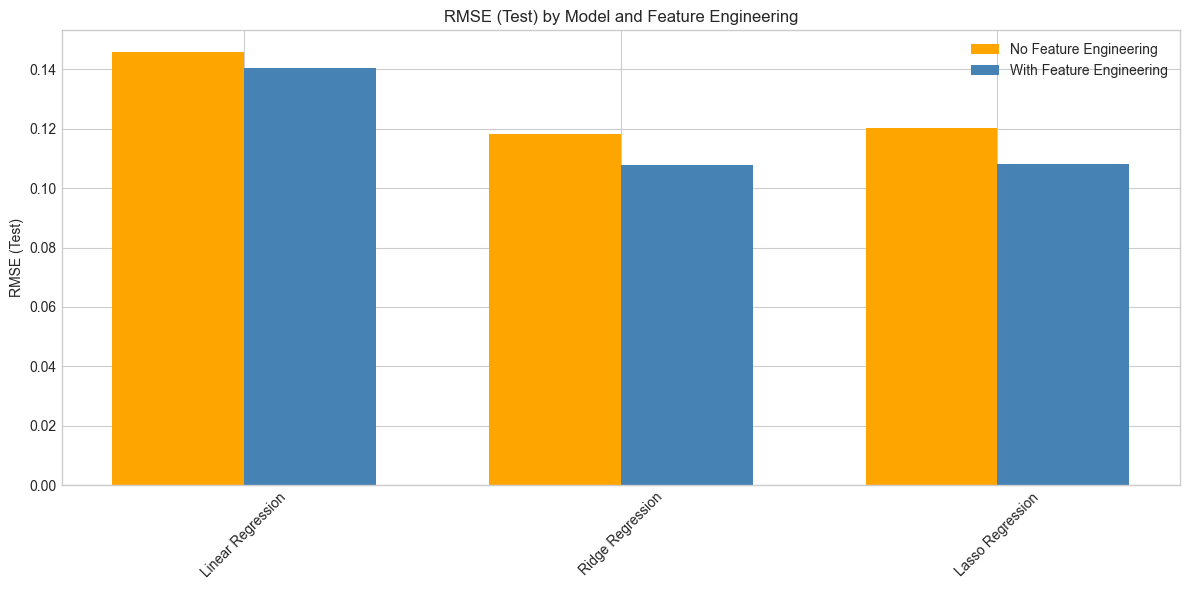

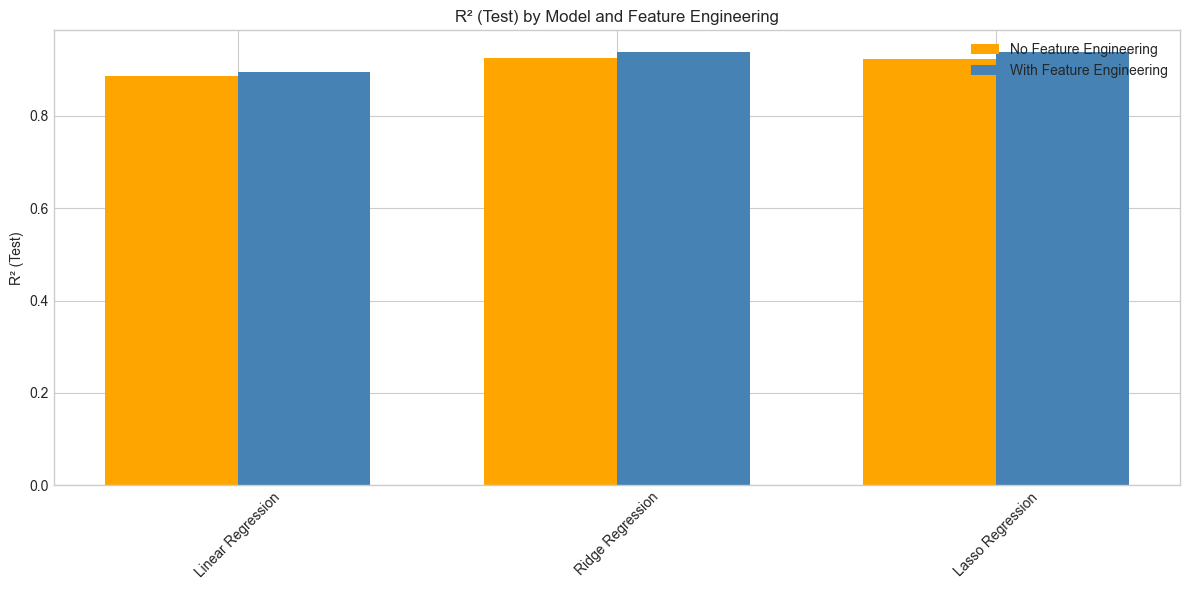

In [19]:
# Create bar charts comparing models
metrics_to_plot = ['RMSE (Test)', 'R² (Test)']
fe_models = [col for col in results_df.columns if 'Feature Engineering' in col]
no_fe_models = [col for col in results_df.columns if 'No Feature Engineering' in col]

for metric in metrics_to_plot:
    plt.figure(figsize=(12, 6))

    model_types = ['Linear Regression', 'Ridge Regression', 'Lasso Regression']
    fe_vals = []
    no_fe_vals = []

    for model in model_types:
        fe_col = f"{model} (Feature Engineering)"
        no_fe_col = f"{model} (No Feature Engineering)"
        if fe_col in results_df.columns and no_fe_col in results_df.columns:
            fe_vals.append(results_df.loc[metric, fe_col])
            no_fe_vals.append(results_df.loc[metric, no_fe_col])

    x = np.arange(len(model_types))  # the label locations
    width = 0.35  # the width of the bars

    plt.bar(x - width/2, no_fe_vals, width, label='No Feature Engineering', color='orange')
    plt.bar(x + width/2, fe_vals, width, label='With Feature Engineering', color='steelblue')

    plt.ylabel(metric)
    plt.title(f'{metric} by Model and Feature Engineering')
    plt.xticks(x, model_types, rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Calculate percentage improvement from feature engineering
improvement_df = pd.DataFrame(index=['RMSE (Test)', 'R² (Test)'])
for base_model in ['Linear Regression', 'Ridge Regression', 'Lasso Regression']:
    fe_model = f"{base_model} (Feature Engineering)"
    no_fe_model = f"{base_model} (No Feature Engineering)"
    
    if fe_model in results_df.columns and no_fe_model in results_df.columns:
        # For RMSE: (no_fe - fe) / no_fe * 100 (reduction is better)
        rmse_improvement = (results_df.loc['RMSE (Test)', no_fe_model] - results_df.loc['RMSE (Test)', fe_model]) / results_df.loc['RMSE (Test)', no_fe_model] * 100
        
        # For R²: (fe - no_fe) / no_fe * 100 (increase is better)
        r2_improvement = (results_df.loc['R² (Test)', fe_model] - results_df.loc['R² (Test)', no_fe_model]) / results_df.loc['R² (Test)', no_fe_model] * 100
        
        improvement_df[base_model] = [rmse_improvement, r2_improvement]


Percentage Improvement from Feature Engineering:
             Linear Regression  Ridge Regression  Lasso Regression
RMSE (Test)           3.787800          8.930985         10.133035
R² (Test)             0.963434          1.393693          1.628256


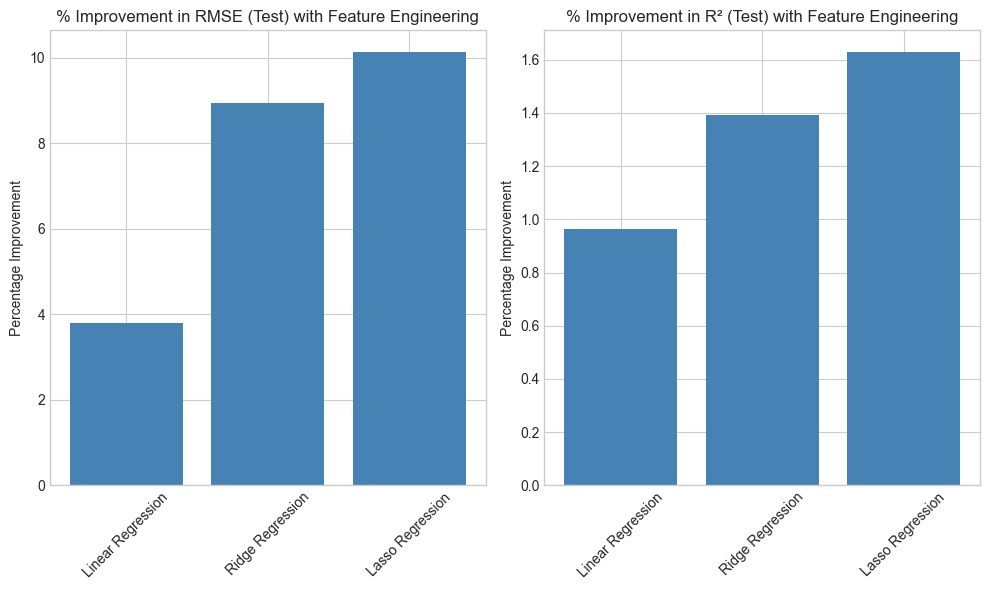

In [20]:
print("\nPercentage Improvement from Feature Engineering:")
print(improvement_df)

# Save improvement results
improvement_df.to_csv('feature_engineering_improvement.csv')

# Create bar chart for improvement percentages
plt.figure(figsize=(10, 6))
for i, metric in enumerate(improvement_df.index):
    plt.subplot(1, 2, i+1)
    plt.bar(improvement_df.columns, improvement_df.loc[metric], color='steelblue')
    plt.title(f'% Improvement in {metric} with Feature Engineering')
    plt.ylabel('Percentage Improvement')
    plt.xticks(rotation=45)
    plt.tight_layout()
plt.show()

## Part 6: Predictions Visualization

Now we will take a look at the predictions of the best model. We will:
1. Identify Best Model Based on RMSE
2. Plot Actual vs Predicted
3. Residuals vs Predicted Values
4. Distribution of Residuals

### Determine predictions from best model
The best model is the one with the lowest RMSE on the test dataset. In this case it is the Ridge Regression model, trained on the feature engineered dataset.

Best model: Ridge Regression (Feature Engineering)


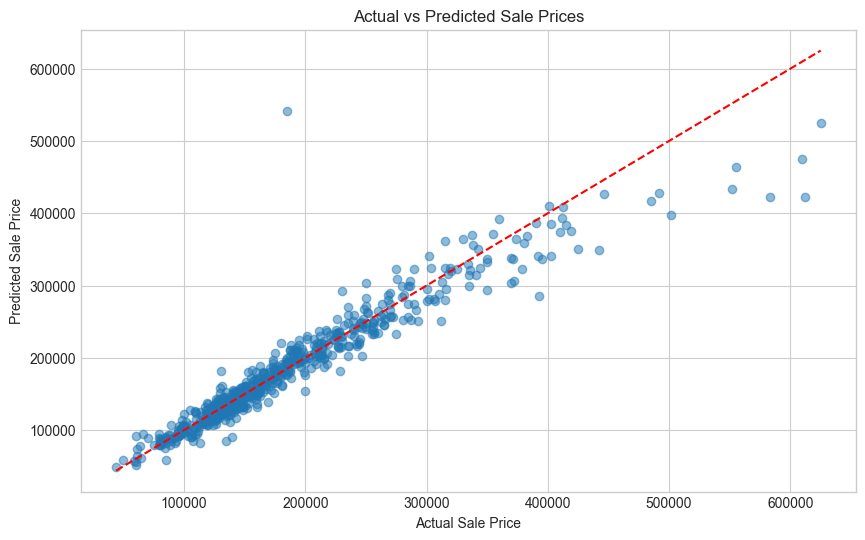

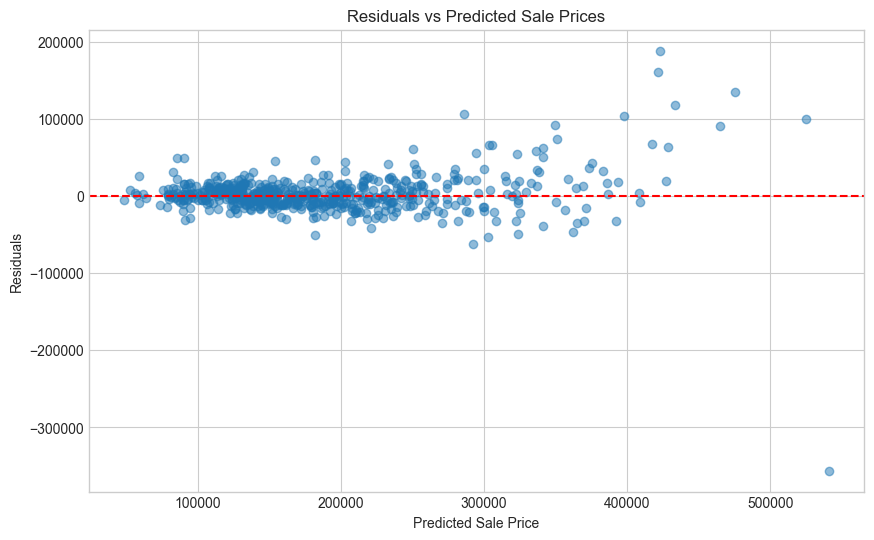

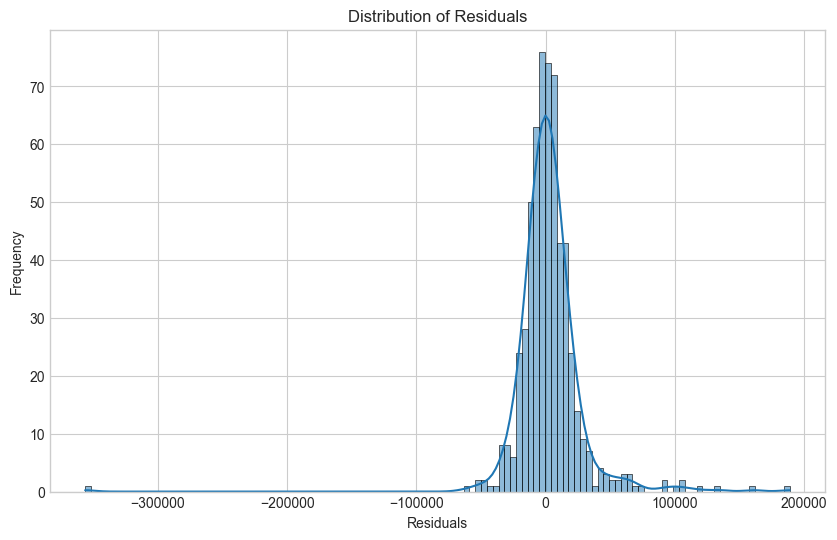

In [21]:
best_model_name = results_df.loc['RMSE (Test)'].idxmin()
best_model = models[best_model_name]
print(f"Best model: {best_model_name}")
if "Feature Engineering" in best_model_name:
    X_test = X_test_fe
    X_train = X_train_fe
    y_test = y_test_fe
    y_train = y_train_fe
else:
    X_test = X_test_no_fe
    X_train = X_train_no_fe
    y_test = y_test_no_fe
    y_train = y_train_no_fe

# Make predictions on test set
y_pred = best_model.predict(X_test)

# Convert back from log scale if necessary
if 'SalePrice_Log' in df.columns:
    y_test_original = np.expm1(y_test)
    y_pred_original = np.expm1(y_pred)
else:
    y_test_original = y_test
    y_pred_original = y_pred

# Plot actual vs predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test_original, y_pred_original, alpha=0.5)
plt.plot([y_test_original.min(), y_test_original.max()], [y_test_original.min(), y_test_original.max()], 'r--')
plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')
plt.title('Actual vs Predicted Sale Prices')
plt.show()

# Calculate residuals
residuals = y_test_original - y_pred_original

# Plot residuals
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_original, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Sale Price')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Sale Prices')
plt.show()

# Plot residuals distribution
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.show()

## Part 7: Feature Importance (according to the feature engineered dataset)
Now we will look into which features were most telling for the feature engineered dataset-trained models when making their predictions. We will:

1. Extract feature names from preprocessor
2. Compute coefficients from trained models
3. Visualize top influential features


In [22]:
# Create a fitted version of the preprocessor (for feature engineering because it will probably be the better model)
# to get feature names
fitted_preprocessor = preprocessor_fe.fit(X_train_fe)

# Extract feature names from preprocessor
def get_feature_names(column_transformer):
    output_features = []
    
    for name, pipe, features in column_transformer.transformers_:
        if name=='passthrough':
            output_features.extend(features)
        elif name=='drop':
            continue
        elif isinstance(pipe, Pipeline):
            # Get the last step of the pipeline
            if hasattr(pipe.steps[-1][1], 'get_feature_names_out'):
                current_features = pipe.steps[-1][1].get_feature_names_out(features)
                output_features.extend(current_features)
            else:
                output_features.extend(features)
        elif hasattr(pipe, 'get_feature_names_out'):
            current_features = pipe.get_feature_names_out(features)
            output_features.extend(current_features)
        else:
            output_features.extend(features)
            
    return output_features

try:
    feature_names = get_feature_names(fitted_preprocessor)
    print(f"Successfully extracted {len(feature_names)} feature names from preprocessor")
except Exception as e:
    print(f"Error extracting feature names: {e}")
    # Fallback to just combining numerical and categorical columns
    numerical_cols = X_train_fe.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_cols = X_train_fe.select_dtypes(include=['object']).columns.tolist()
    
    # Get the feature names for numerical features (these stay the same)
    numerical_features = numerical_cols
    
    # Get the one-hot encoded feature names for categorical features
    ohe_feature_names = fitted_preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols)
    # Combine the numerical and one-hot encoded feature names
    feature_names = np.append(numerical_features, ohe_feature_names)
    # feature_names = numerical_cols + [f"cat_{col}" for col in categorical_cols]
    print(f"Using fallback feature names with {len(feature_names)} features")

# Extract coefficients from models
def get_feature_importance(model_name, feature_names):
    if model_name not in models:
        return None
    
    # Make sure the model has been fitted
    if not hasattr(models[model_name].named_steps['regressor'], 'coef_'):
        print(f"Model {model_name} does not have coefficients. Fitting first...")
        models[model_name].fit(X_train, y_train)
    
    coefs = models[model_name].named_steps['regressor'].coef_
    
    # Some models might have different shapes of coefficients
    if len(coefs) != len(feature_names):
        # print(f"Warning: Number of coefficients ({len(coefs)}) doesn't match number of features ({len(feature_names)})")
        # Try to adjust feature_names or coefficients
        if len(coefs) < len(feature_names):
            feature_names = feature_names[:len(coefs)]
        else:
            coefs = coefs[:len(feature_names)]
    
    # Create DataFrame with feature names and coefficients
    feature_importance = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefs})
    feature_importance = feature_importance.sort_values('Coefficient', key=abs, ascending=False)
    return feature_importance

Error extracting feature names: input_features is not equal to feature_names_in_
Using fallback feature names with 372 features



Top 15 features by importance (Ridge Regression (Feature Engineering)):
                   Feature  Coefficient
75             TotalSF_Log     0.065802
5              OverallQual     0.050427
80           GrLivArea_Log     0.048400
74            1stFlrSF_Log     0.042230
91      Neighborhood_Price     0.041743
366  SaleCondition_Abnorml    -0.039478
199    Exterior1st_BrkFace     0.031550
130   Neighborhood_Crawfor     0.027578
40         OverallQualCond     0.026162
90         OverallCond_Log     0.025849
73         LotFrontage_Log     0.025642
76          BsmtFinSF1_Log     0.023515
15                2ndFlrSF     0.023389
79       ExterCond_Num_Log     0.021180
3              LotFrontage    -0.020856


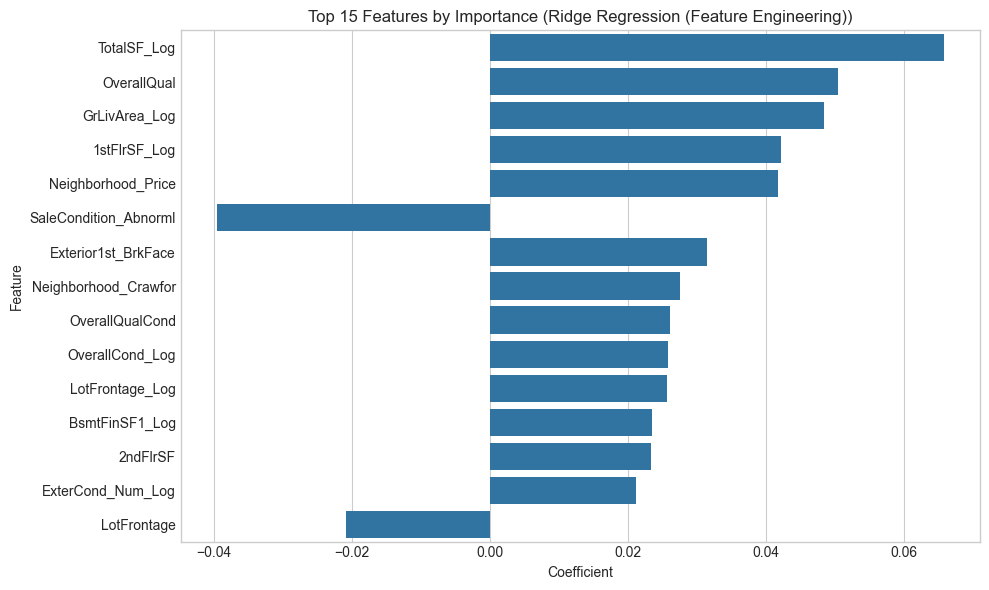


Top 15 features by importance (Lasso Regression (Feature Engineering)):
                   Feature  Coefficient
75             TotalSF_Log     0.149906
366  SaleCondition_Abnorml    -0.086680
5              OverallQual     0.066467
199    Exterior1st_BrkFace     0.050994
91      Neighborhood_Price     0.048111
130   Neighborhood_Crawfor     0.045210
74            1stFlrSF_Log     0.038943
90         OverallCond_Log     0.038464
290           CentralAir_N    -0.036863
61             LotArea_Log     0.031457
127   Neighborhood_BrkSide     0.030919
308         Functional_Typ     0.030029
154        Condition1_Norm     0.029897
14                1stFlrSF    -0.029579
241           ExterCond_TA     0.028145


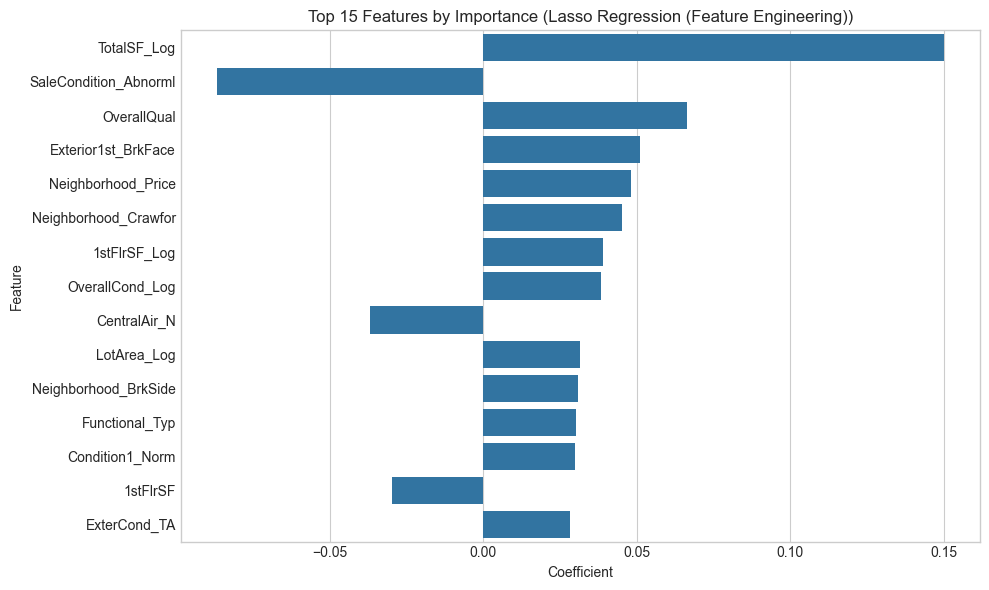

In [23]:
# Get feature importance for each model
for model_name in ['Ridge Regression (Feature Engineering)', 'Lasso Regression (Feature Engineering)']:
    try:
        importance = get_feature_importance(model_name, feature_names)
        if importance is not None:
            print(f"\nTop 15 features by importance ({model_name}):")
            print(importance.head(15))
            
            # Plot feature importance
            plt.figure(figsize=(10, 6))
            top_features = importance.head(15)
            sns.barplot(x='Coefficient', y='Feature', data=top_features)
            plt.title(f'Top 15 Features by Importance ({model_name})')
            plt.tight_layout()
            plt.show()
    except Exception as e:
        print(f"Error getting feature importance for {model_name}: {e}")

## Part 8: Conclusion

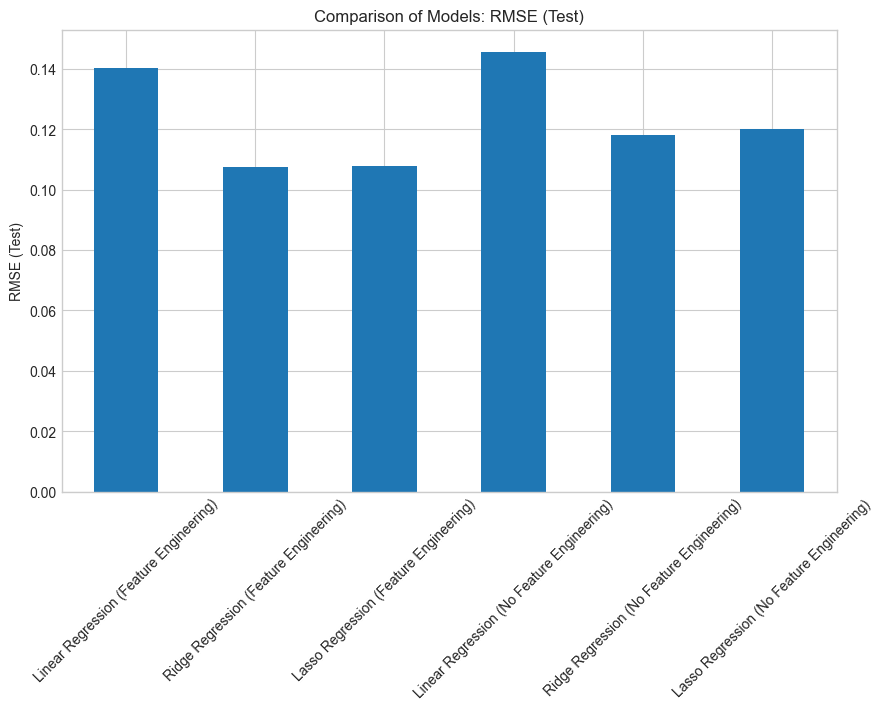

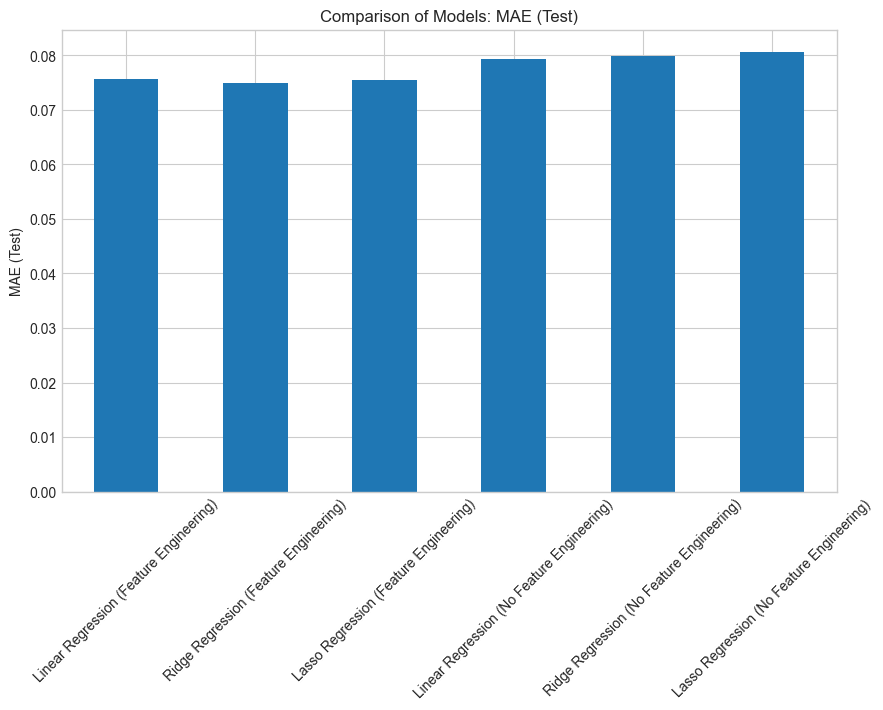

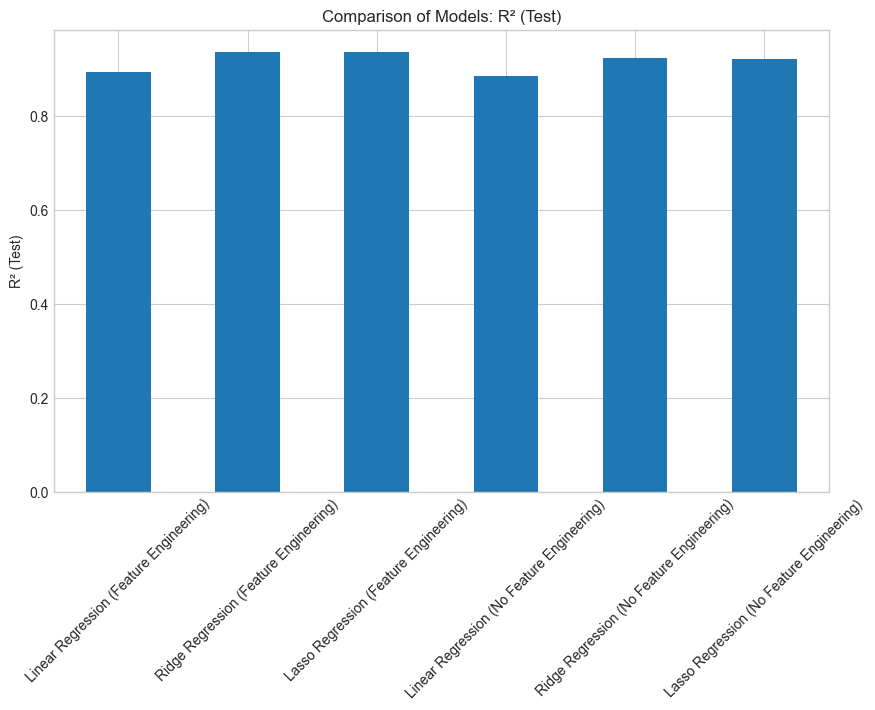

In [24]:
# Compare all models with bar chart
metrics = ['RMSE (Test)', 'MAE (Test)', 'R² (Test)']
for metric in metrics:
    plt.figure(figsize=(10, 6))
    results_df.loc[metric].plot(kind='bar')
    plt.title(f'Comparison of Models: {metric}')
    plt.ylabel(metric)
    plt.xticks(rotation=45)
    plt.show()

### Summary of findings

In [25]:
print("Summary of Model Comparison:")
print(f"1. Best model with feature engineering: {results_df.loc['RMSE (Test)'][fe_models].idxmin()}")
print(f"2. Best model without feature engineering: {results_df.loc['RMSE (Test)'][no_fe_models].idxmin()}")

best_overall = results_df.loc['RMSE (Test)'].idxmin()
print(f"3. Best overall model: {best_overall}")

if 'SalePrice_Log' in df.columns:
    print("4. Log transformation was applied to the target variable to handle skewness")
else:
    print("4. No transformation was needed for the target variable")

print("\n5. Top features affecting housing prices:")
try:
    importance = get_feature_importance(best_model_name, feature_names)
    if importance is not None:
        for i, (feature, coef) in enumerate(zip(importance['Feature'].head(5), importance['Coefficient'].head(5))):
            print(f"   {i+1}. {feature}: {coef:.4f}")
except:
    print("   Could not determine feature importance")

print("\n6. Feature engineering impact:")
print(f"   - Original number of features: {df.shape[1] - 2}")  # Excluding Id and SalePrice
print(f"   - Features after engineering: {df_fe.shape[1]}")
print(f"   - New features created: {df_fe.shape[1] - (df.shape[1] - 2)}")

# Calculate average improvement across models
avg_rmse_improvement = improvement_df.loc['RMSE (Test)'].mean()
avg_r2_improvement = improvement_df.loc['R² (Test)'].mean()

print(f"   - Average RMSE reduction from feature engineering: {avg_rmse_improvement:.2f}%")
print(f"   - Average R² improvement from feature engineering: {avg_r2_improvement:.2f}%")

print("\n7. Regularization impact:")
linear_rmse_fe = results_df.loc['RMSE (Test)', 'Linear Regression (Feature Engineering)']
linear_rmse_no_fe = results_df.loc['RMSE (Test)', 'Linear Regression (No Feature Engineering)']
ridge_rmse_fe = results_df.loc['RMSE (Test)', 'Ridge Regression (Feature Engineering)']
ridge_rmse_no_fe = results_df.loc['RMSE (Test)', 'Ridge Regression (No Feature Engineering)']
lasso_rmse_fe = results_df.loc['RMSE (Test)', 'Lasso Regression (Feature Engineering)']
lasso_rmse_no_fe = results_df.loc['RMSE (Test)', 'Lasso Regression (No Feature Engineering)']
    
print(f"   - Linear Regression RMSE (FE): {linear_rmse_fe:.2f}")
print(f"   - Linear Regression RMSE (No FE): {linear_rmse_no_fe:.2f}")
print(f"   - Ridge Regression RMSE (FE): {ridge_rmse_fe:.2f}")
print(f"   - Ridge Regression RMSE (No FE): {ridge_rmse_no_fe:.2f}")
print(f"   - Lasso Regression RMSE (FE): {lasso_rmse_fe:.2f}")
print(f"   - Lasso Regression RMSE (No FE): {lasso_rmse_no_fe:.2f}")
    
best_reg = min([(linear_rmse_fe, 'Linear (FE)'), (linear_rmse_no_fe, 'Linear (No FE)'),
        (ridge_rmse_fe, 'Ridge (FE)'), (ridge_rmse_no_fe, 'Ridge (No FE)'),
        (lasso_rmse_fe, 'Lasso (FE)'), (lasso_rmse_no_fe, 'Lasso (No FE)')], 
         key=lambda x: x[0])[1]
print(f"   - Best regularization technique: {best_reg}")

print("\nThis project has demonstrated the effectiveness of regularized linear regression")
print("techniques for predicting housing prices and identified the key factors that")
print("influence property values in the Ames, Iowa housing market. It also demonstrated the")
print("significant impact of feature engineering on housing price prediction models.")
print("It consistently improved model performance across all regression techniques, with the")
print(f"best overall model being {best_overall}.")
      

Summary of Model Comparison:
1. Best model with feature engineering: Ridge Regression (Feature Engineering)
2. Best model without feature engineering: Ridge Regression (No Feature Engineering)
3. Best overall model: Ridge Regression (Feature Engineering)
4. Log transformation was applied to the target variable to handle skewness

5. Top features affecting housing prices:
   1. TotalSF_Log: 0.0658
   2. OverallQual: 0.0504
   3. GrLivArea_Log: 0.0484
   4. 1stFlrSF_Log: 0.0422
   5. Neighborhood_Price: 0.0417

6. Feature engineering impact:
   - Original number of features: 81
   - Features after engineering: 310
   - New features created: 229
   - Average RMSE reduction from feature engineering: 7.62%
   - Average R² improvement from feature engineering: 1.33%

7. Regularization impact:
   - Linear Regression RMSE (FE): 0.14
   - Linear Regression RMSE (No FE): 0.15
   - Ridge Regression RMSE (FE): 0.11
   - Ridge Regression RMSE (No FE): 0.12
   - Lasso Regression RMSE (FE): 0.11
   -